# Sine-Gordon Solver

In [76]:
import numpy as np
import matplotlib.pyplot as plt

## Initial Setup

In [77]:
# Inputs Parameters
a = 0.0
b = 3.14
n = 100          # number of subintervals
K = 2            # positive integer
# shape parameters 
c = 1.027
s = 0.8



In [78]:
# Check that N = n/K is an integer
if n % K != 0:
    raise ValueError("n must be divisible by K.")

N = n // K
if N < 2:
    raise ValueError("Need at least two interpolation centers.")

# Grid points x_i, i = 0,...,n
x = np.linspace(a, b, n + 1)
f = np.sin(x)

# Interpolation centers x_{k_j}; keep both values and indices.
# Eq. (13) requires 0 < k_1 < ... < k_N < n so divided differences
# can use x_{k_j-1}, x_{k_j}, x_{k_j+1}.
k_idx = np.rint(np.linspace(1, n - 1, N)).astype(int)
k_idx[0] = 1
k_idx[-1] = n - 1

if len(np.unique(k_idx)) != N:
    raise ValueError("Center selection produced duplicate indices; increase n or reduce K.")

xk = x[k_idx]

print("Grid points x_i:")
print(x)

print()
print("Interpolation center indices k_j:")
print(k_idx)

print()
print("Interpolation centers x_{k_j}:")
print(xk)


Grid points x_i:
[0.     0.0314 0.0628 0.0942 0.1256 0.157  0.1884 0.2198 0.2512 0.2826
 0.314  0.3454 0.3768 0.4082 0.4396 0.471  0.5024 0.5338 0.5652 0.5966
 0.628  0.6594 0.6908 0.7222 0.7536 0.785  0.8164 0.8478 0.8792 0.9106
 0.942  0.9734 1.0048 1.0362 1.0676 1.099  1.1304 1.1618 1.1932 1.2246
 1.256  1.2874 1.3188 1.3502 1.3816 1.413  1.4444 1.4758 1.5072 1.5386
 1.57   1.6014 1.6328 1.6642 1.6956 1.727  1.7584 1.7898 1.8212 1.8526
 1.884  1.9154 1.9468 1.9782 2.0096 2.041  2.0724 2.1038 2.1352 2.1666
 2.198  2.2294 2.2608 2.2922 2.3236 2.355  2.3864 2.4178 2.4492 2.4806
 2.512  2.5434 2.5748 2.6062 2.6376 2.669  2.7004 2.7318 2.7632 2.7946
 2.826  2.8574 2.8888 2.9202 2.9516 2.983  3.0144 3.0458 3.0772 3.1086
 3.14  ]

Interpolation center indices k_j:
[ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47
 49 51 53 55 57 59 61 63 65 67 69 71 73 75 77 79 81 83 85 87 89 91 93 95
 97 99]

Interpolation centers x_{k_j}:
[0.0314 0.0942 0.157  0.2198 0.2826 0.3454 

## Functions
### Wu-Schaback radial basis function
$$\varphi(r) = \frac{s^2}{(s^2 + r^2)^{3/2}},\tag{7}$$

where $\emph{s}$ is a shape parameter.

### Multiquadric basis function
$$ \phi_i(x) = \sqrt{c^2 + (x - x_i)^2} \tag{10}$$
$ c \in \mathbb{R}^+ $ is a shape parameter.

In [79]:
# Eq. (7):  Wu-Schaback radial basis function

def varphi(r, s):
    """ φ(r) = s^2 / (s^2 + r^2)^(3/2)   """
    return s**2 / (s**2 + r**2)**1.5

# Eq. (10): Multiquadric basis function

def phi(a, b, c):
    """    φ_i(x) = sqrt(c^2 + (x - x_i)^2)    """
    return np.sqrt(c**2 + (a - b)**2)

### Wu--Schaback's $\mathcal{L}_{\mathcal{D}}$ operator
$$

(\mathcal{L}_{\mathcal{D}})f(x_{i}) = \sum_{j=0}^{n} f_j \psi_j(x_{i})  \quad i = 1, \dots, n.
$$
where
$$
f_j = f(x_{j})  \\
\psi_{0}(x) = \frac{1}{2} + \frac{\phi_{1}(x) - (x - x_{0})}{2(x_{1} - x_{0})}, \\
\psi_{1}(x) = \frac{\phi_{2}(x) - \phi_{1}(x)}{2(x_{2} - x_{1})} - \frac{\phi_{1}(x) - (x - x_{0})}{2(x_{1} - x_{0})}, \\
\psi_{n-1}(x) = \frac{-1 - \phi_{n-1}(x)}{2(x_{n} - x_{n-1})} - \frac{\phi_{n-1}(x) - \phi_{n-2}(x)}{2(x_{n-1} - x_{n-2})}, \\
\psi_{n}(x) = \frac{1}{2} + \frac{\phi_{n-1}(x) - -1}{2(x_{n} - x_{n-1})}, \\
\psi_{j}(x) = \frac{\phi_{j+1}(x) - \phi_{j}(x)}{2(x_{j+1} - x_{j})} - \frac{\phi_{j}(x) - \phi_{j-1}(x)}{2(x_{j} - x_{j-1})}, \quad j = 2, \dots, n - 2. \tag{12}
 $$

In [80]:

def psi(a, j, x, c):
    """
    Compute psi_j(a) from Eq. (12) on the node set x.
    """

    n = len(x) - 1
    if j == 0:
        return (0.5 + (phi(a, x[1], c) - (a - x[0])) / (2 * (x[1] - x[0])))

    elif j == 1:
        return ((phi(a, x[2], c) - phi(a, x[1], c)) / (2 * (x[2] - x[1]))
                -
                (phi(a, x[1], c) - (a - x[0])) / (2 * (x[1] - x[0]))
                )

    elif j == n - 1:
        return (((x[n] - a) - phi(a, x[n - 1], c)) / (2 * (x[n] - x[n - 1]))
                -
                (phi(a, x[n - 1], c) - phi(a, x[n - 2], c)) / (2 * (x[n - 1] - x[n - 2]))
                )

    elif j == n:
        return (0.5 + (phi(a, x[n - 1], c) - (x[n] - a)) / (2 * (x[n] - x[n - 1])))

    else:
        return ((phi(a, x[j + 1], c) - phi(a, x[j], c)) / (2 * (x[j + 1] - x[j]))
                -
                (phi(a, x[j], c) - phi(a, x[j - 1], c)) / (2 * (x[j] - x[j - 1]))
                )


In [81]:
def LD_operator(a, i, x, f, c):
    """
    Wu-Schaback interpolation operator
        (L_D f)(x) = Σ f_j ψ_j(x)
    """
    # print(x)
    # print(f)
    d = []
    for j in range(len(x)):
        d.append(psi(a, j, x, c))
    return np.asarray(f) @ np.asarray(d)

In [82]:
print(LD_operator(x[0], 0, x, f, c))

-0.3504339333508701


### $2^{nd}$ Derivative of $f(x)$ using $2^{nd}$=divided difference 
$$f_{x_{k_j}''}'' = \frac{2\Big[(x_{k_j} - x_{k_j-1})f(x_{k_j+1}) - (x_{k_j+1} - x_{k_j-1})f(x_{k_j}) + (x_{k_j+1} - x_{k_j})f(x_{k_j-1})\Big]}{(x_{k_j} - x_{k_j-1})(x_{k_j+1} - x_{k_j})(x_{k_j+1} - x_{k_j-1})}\,$$



In [83]:

def second_divided_difference(x, f, kj):
    """
    Approximation of f''(x_{k_j}) using three-point
    nonuniform divided differences.
    """

    if kj <= 0 or kj >= len(x) - 1:
        raise ValueError("kj must be a strictly interior grid index.")

    xm = x[kj - 1]
    x0 = x[kj]
    xp = x[kj + 1]

    fm = f[kj - 1]
    f0 = f[kj]
    fp = f[kj + 1]

    numerator = 2.0 * (
        (x0 - xm) * fp
        - (xp - xm) * f0
        + (xp - x0) * fm
    )

    denominator = (
        (x0 - xm)
        * (xp - x0)
        * (xp - xm)
    )

    return numerator / denominator


## Solving for $\alpha_{j}$

$$S_{f''}(\mathbf{x}_{k_i}) = \sum_{j=1}^{N} \alpha_j \varphi(\|\mathbf{x}_{k_i} - \mathbf{x}_{k_j}\|) = f''(\mathbf{x}_{k_i}), \quad i = 1, \dots, N.\tag{15}$$


$$ \alpha_m = \sum_{i=1}^{N}\left[A^{-1}\right]_{mi} f''(\mathbf{x}_{k_i}), \quad m = 1, \dots, N.$$
$$A_{ij}=\varphi(|x_{k_i}-x_{k_j}|)$$

In [95]:
def rbf_matrix(xk, s):
    """
    A_ij = varphi(|x_{k_i} - x_{k_j}|)
    """

    r = np.abs(xk[:, None] - xk[None, :])

    A = varphi(r, s)

    return A


In [85]:

from SPD_solver import solve_spd

A = rbf_matrix(xk, s)
rhs = []
for kj in k_idx:
    rhs.append(second_divided_difference(x, f, kj))

alpha = solve_spd(A, rhs)
print(alpha)


[    289.35521665   -1990.07859668    6991.75473188  -16865.05807701
   31654.68786319  -49629.74915348   68058.2621619   -84294.3872588
   96523.33856267 -103973.42780302  106742.11894641 -105472.80037403
  101046.37957591  -94362.87879598   86216.06783697  -77242.87837501
   67916.20479257  -58563.40372904   49391.29769869  -40514.24327625
   31976.37776758  -23771.98881283   15858.88864529   -8171.0755027
     626.13428989    6866.08180221  -14398.44520198   22058.93995052
  -29925.70400599   38058.51198267  -46491.75494109   55222.44943766
  -64197.83449955   73296.19465841  -82305.87723637   90898.35664351
  -98604.05068628  104794.22661864 -108688.23328782  109403.85753982
 -106082.23345122   98105.29679844  -85402.18342649   68768.81372286
  -50036.67378745   31855.56933973  -16946.32809526    7016.67516675
   -1995.12461679     289.84420105]


$$e(x_{i}) = f(x_{i}) - \sum_{j=1}^{N} \alpha_j \sqrt{s^2 + (x_{i} - x_{k_j})^2}  \quad i = 1, \dots, n. \\
e(x_{i}) = f(x_{i}) - R(x_{i})  \quad i = 1, \dots, n.\tag{16}$$

In [86]:

def rbf_correction(a, xk, alpha, s):
    """
    R(x) = sum_j alpha_j sqrt(s^2 + (x-x_{k_j})^2)
    """

    M = []
    for j in range(len(xk)):
        M.append(np.sqrt(s**2 + (a - xk[j])**2))

    return np.asarray(M) @ alpha


def error_function(i, x, f, xk, alpha, s):
    """
    e(x_i) = f(x_i) - sum_j alpha_j sqrt(s^2 + (x_i-x_{k_j})^2)
    """

    return f[i] - rbf_correction(x[i], xk, alpha, s)


$$\mathcal{L}_{w_2} f(x_{i}) = \sum_{j=1}^{N} \alpha_j \sqrt{s^2 + (x_{i} - x_{k_j})^2} + \mathcal{L}_{\mathcal{D}} e(x_{i})  \quad i = 1, \dots, n.\tag{17}$$

In [87]:

def L_W2(i, x, f, xk, alpha, s, c):
    """
    Wu-Schaback L_W2 operator

        L_W2 f(x) = sum_j alpha_j sqrt(s^2 + (x-x_{k_j})^2) + L_D e(x)
    """

    # First term: sum_j alpha_j sqrt(s^2 + (x-x_{k_j})^2)
    rbf_part = rbf_correction(x[i], xk, alpha, s)

    # Eq. (17) applies L_D to the full residual data {x_i, e(x_i)}_{i=0}^n.
    e_vals = []
    for p in range(len(x)):
        e_vals.append(error_function(p, x, f, xk, alpha, s))

    ld_part = LD_operator(x[i], i, x, e_vals, c)
    return rbf_part + ld_part


In [88]:
L_W2_values = np.array([L_W2(i, x, f, xk, alpha, s, c) for i in range(len(x))])

In [89]:
# print(f - L_W2_values)

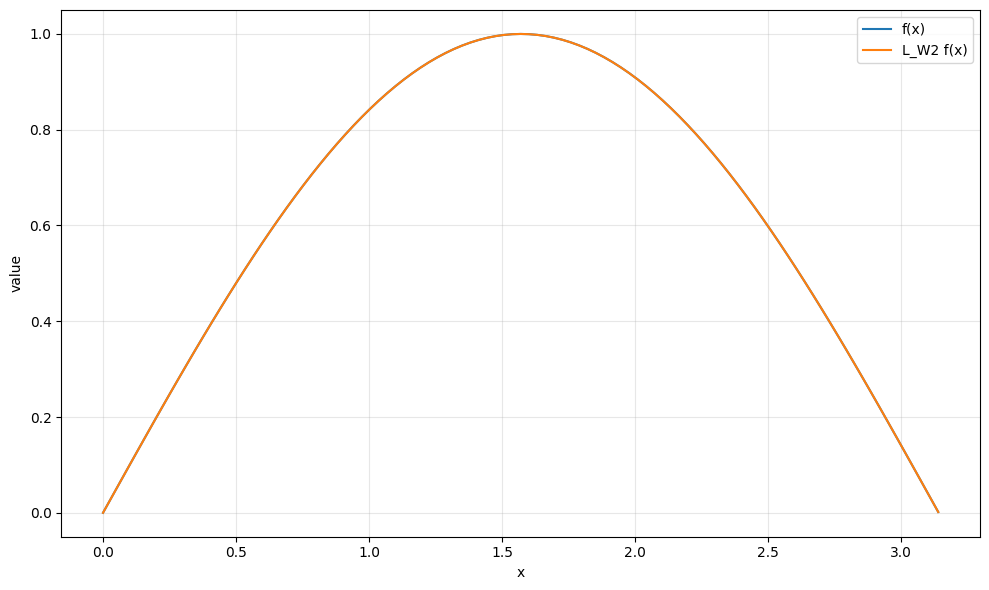

In [90]:
L_W2_values = np.array([L_W2(i, x, f, xk, alpha, s, c) for i in range(len(x))])

plt.figure(figsize=(10, 6))
plt.plot(x, f, '-', label='f(x)')
plt.plot(x, L_W2_values, '-', label='L_W2 f(x)')
plt.xlabel('x')
plt.ylabel('value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


$$(\mathcal{L}_{\mathcal{W}_2} f)''(x) = \sum_{j=1}^N \alpha_j \varphi(x - x_{k_j}) + \sum_{i=0}^n \left( f(x_i) - \sum_{j=1}^N \alpha_j \sqrt{s^2 + (x_i - x_{k_j})^2} \right) \psi_i''(x),$$

where
$$
\psi_{0}''(x) = \frac{\phi^{''}_{1}(x)}{2(x_{1} - x_{0})}, \\
\psi_{1}''(x) = \frac{\phi^{''}_{2}(x) - \phi^{''}_{1}(x)}{2(x_{2} - x_{1})} - \frac{\phi^{''}_{1}(x)}{2(x_{1} - x_{0})}, \\
\psi_{n-1}''(x) = \frac{-\phi_{n-1}''(x)}{2(x_{n} - x_{n-1})} - \frac{\phi_{n-1}''(x) - \phi_{n-2}''(x)}{2(x_{n-1} - x_{n-2})}, \\
\psi_{n}''(x) = \frac{\phi_{n-1}''(x)}{2(x_{n} - x_{n-1})}, \\
\psi_{j}''(x) = \frac{\phi_{j+1}''(x) - \phi_{j}''(x)}{2(x_{j+1} - x_{j})} - \frac{\phi_{j}''(x) - \phi_{j-1}''(x)}{2(x_{j} - x_{j-1})}, \quad j = 2, \dots, n - 2. \\$$

$$\varphi(r) = \frac{s^2}{(s^2 + r^2)^{3/2}}$$
where $\emph{s}$ is a shape parameter.
$$\phi^{''}_{i}(x)=c^2\left(c^2+(x-x_i)^2\right)^{-3/2}$$
$ c \in \mathbb{R}^+ $ is a shape parameter.

In [91]:
def d2_phi(a, b, c):
    return c**2 / (c**2 + (a - b)**2)**1.5


def d2_psi(a, j, x, c):
    """
    Second derivative of psi_j(x).
    """
    n = len(x) - 1

    if j == 0:
        return d2_phi(a, x[1], c) / (2 * (x[1] - x[0]))

    elif j == 1:
        return ((d2_phi(a, x[2], c) - d2_phi(a, x[1], c))
                / (2 * (x[2] - x[1]))
                -
                d2_phi(a, x[1], c)
                / (2 * (x[1] - x[0])))

    elif j == n - 1:
        return (-d2_phi(a, x[n - 1], c)
                / (2 * (x[n] - x[n - 1]))
                -
                (d2_phi(a, x[n - 1], c) - d2_phi(a, x[n - 2], c))
                / (2 * (x[n - 1] - x[n - 2])))

    elif j == n:
        return d2_phi(a, x[n - 1], c) / (2 * (x[n] - x[n - 1]))

    else:
        return ((d2_phi(a, x[j + 1], c) - d2_phi(a, x[j], c))
                / (2 * (x[j + 1] - x[j]))
                -
                (d2_phi(a, x[j], c) - d2_phi(a, x[j - 1], c))
                / (2 * (x[j] - x[j - 1])))

In [92]:
def d2_L_W2(i, x, f, xk, alpha, s, c):
    """
    Second derivative of the Wu-Schaback operator

        (L_W2 f)''(x)  = Σ_j α_j varphi(x-x_{k_j}) + Σ_i e(x_i) ψ_i''(x)

    """

    xx = x[i]

    # First term:
    # Σ_j α_j varphi(xx - xk_j)

    rbf_part = 0.0
    for j in range(len(alpha)):
        rbf_part += alpha[j] * varphi(xx - xk[j], s)

    # Residual values e(x_i)

    e_vals = np.zeros(len(x))
    for p in range(len(x)):
        e_vals[p] = error_function(p, x, f, xk, alpha, s)

    # Σ_i e(x_i) ψ_i''(xx)

    ld_part = 0.0
    for p in range(len(x)):
        ld_part += e_vals[p] * d2_psi(xx, p, x, c)

    return rbf_part + ld_part

In [93]:
d2_f = -np.sin(x)  # FIX: f = sin(x), so the exact second derivative is f'' = -sin(x), not cos(x).

d2_L_W2_values = np.array([d2_L_W2(i, x, f, xk, alpha, s, c) for i in range(len(x))])  # FIX: Eq. 17A differentiates L_W2 built from the original f values; d2_f is only for comparison.

# print(d2_f - d2_L_W2_values)

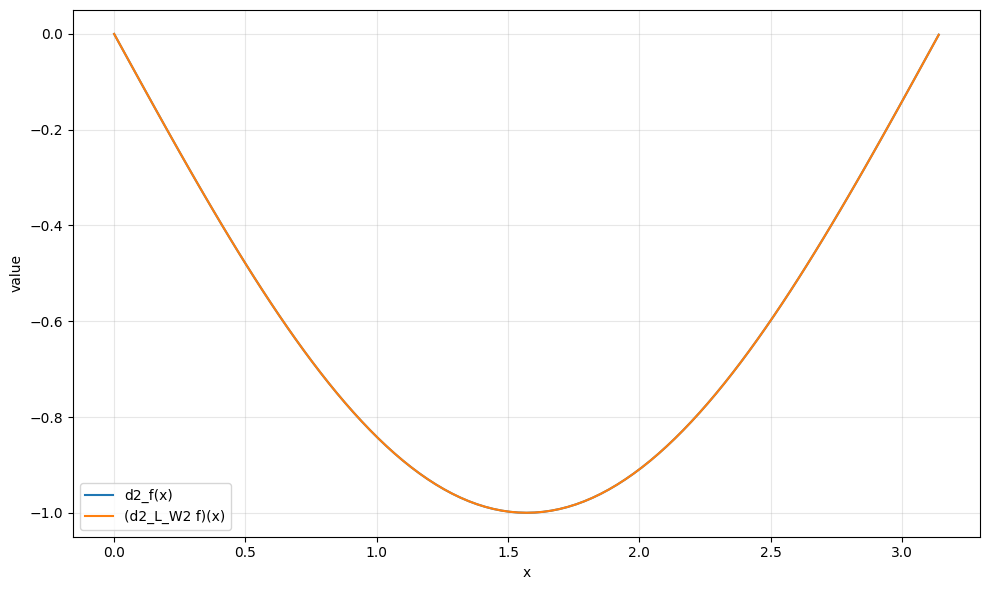

In [94]:

plt.figure(figsize=(10, 6))
plt.plot(x, d2_f, '-', label='d2_f(x)')
plt.plot(x, d2_L_W2_values, '-', label='(d2_L_W2 f)(x)')
plt.xlabel('x')
plt.ylabel('value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()